In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import TimeSeriesSplit
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

input_file = "data/APL_data"  
output_file = "data/APL_data.csv"  

df = pd.read_csv(input_file, delimiter="\t")  
df.to_csv(output_file, index=False)  

FileNotFoundError: [Errno 2] No such file or directory: 'data/APL_data'

In [2]:
df.head(50)

,% # Apple Stock Price Trend Prediction Dataset (2014-2023)
0,%
1,% ## Dataset Overview
2,% Apple stock prices from years 2014 to 2023. ...
3,%
4,%
5,@RELATION Apple_Stock_Price_Trends
6,@ATTRIBUTE open REAL
7,@ATTRIBUTE high REAL
8,@ATTRIBUTE low REAL
9,@ATTRIBUTE close REAL


In [3]:
# Define the column names based on the dataset attributes
columns = [
    "open", "high", "low", "close", "volume", "rsi_7", "rsi_14", "cci_7", "cci_14",
    "sma_50", "ema_50", "sma_100", "ema_100", "macd", "bollinger", "truerange",
    "atr_7", "atr_14", "target", "year", "month", "day", "weekday"
]

df = pd.read_csv(
    "APL_data.csv",  
    skiprows=31,  
    delimiter=",",  
    quotechar="'",  
    names=columns,  
    engine="python",  
)



In [4]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

         open       high        low      close     volume      rsi_7  \
0  "19.845715  19.893929  19.715000  19.754642  234684800  44.149614   
1  "19.745001  19.775000  19.301071  19.320715  392467600  33.094332   
2  "19.194643  19.528570  19.057142  19.426071  412610800  37.525661   
3  "19.440001  19.498571  19.211430  19.287144  317209200  34.055624   
4  "19.243214  19.484285  19.238930  19.409286  258529600  39.768497   

      rsi_14       cci_7      cci_14     sma_50  ...      macd  bollinger  \
0  50.996175 -105.071637  -42.411877  19.282236  ...  0.194637  19.979268   
1  43.883529 -152.150999 -124.511983  19.297314  ...  0.132887  19.936375   
2  45.858019 -132.306490 -130.122350  19.310864  ...  0.091398  19.893571   
3  43.675708  -89.587009 -108.089019  19.316671  ...  0.046768  19.857893   
4  46.104107  -58.525539  -82.150032  19.329171  ...  0.021012  19.816875   

   truerange     atr_7    atr_14   target  year  month day  weekday  
0   0.321428  0.305722  0.316301  

In [5]:
#Convert 'open' to float
df['open'] = df['open'].str.replace('"', '').astype(float)
# Remove quotes from all columns and convert to appropriate types
df = df.apply(lambda x: x.str.replace('"', '') if x.dtype == 'object' else x)
print(df.columns)
print(df.dtypes)

Index(['open', 'high', 'low', 'close', 'volume', 'rsi_7', 'rsi_14', 'cci_7',
       'cci_14', 'sma_50', 'ema_50', 'sma_100', 'ema_100', 'macd', 'bollinger',
       'truerange', 'atr_7', 'atr_14', 'target', 'year', 'month', 'day',
       'weekday'],
      dtype='object')
open         float64
high         float64
low          float64
close        float64
volume         int64
rsi_7        float64
rsi_14       float64
cci_7        float64
cci_14       float64
sma_50       float64
ema_50       float64
sma_100      float64
ema_100      float64
macd         float64
bollinger    float64
truerange    float64
atr_7        float64
atr_14       float64
target        object
year           int64
month          int64
day            int64
weekday       object
dtype: object


In [6]:
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df = df.drop(['year', 'month', 'day'], axis=1)   
print(df.head())                          

        open       high        low      close     volume      rsi_7  \
0  19.845715  19.893929  19.715000  19.754642  234684800  44.149614   
1  19.745001  19.775000  19.301071  19.320715  392467600  33.094332   
2  19.194643  19.528570  19.057142  19.426071  412610800  37.525661   
3  19.440001  19.498571  19.211430  19.287144  317209200  34.055624   
4  19.243214  19.484285  19.238930  19.409286  258529600  39.768497   

      rsi_14       cci_7      cci_14     sma_50  ...    sma_100    ema_100  \
0  50.996175 -105.071637  -42.411877  19.282236  ...  18.372604  18.484713   
1  43.883529 -152.150999 -124.511983  19.297314  ...  18.398896  18.501371   
2  45.858019 -132.306490 -130.122350  19.310864  ...  18.418311  18.519794   
3  43.675708  -89.587009 -108.089019  19.316671  ...  18.433146  18.535080   
4  46.104107  -58.525539  -82.150032  19.329171  ...  18.449414  18.552493   

       macd  bollinger  truerange     atr_7    atr_14   target weekday  \
0  0.194637  19.979268   0.321

In [7]:
df = df.drop(columns=['target'], errors='ignore')

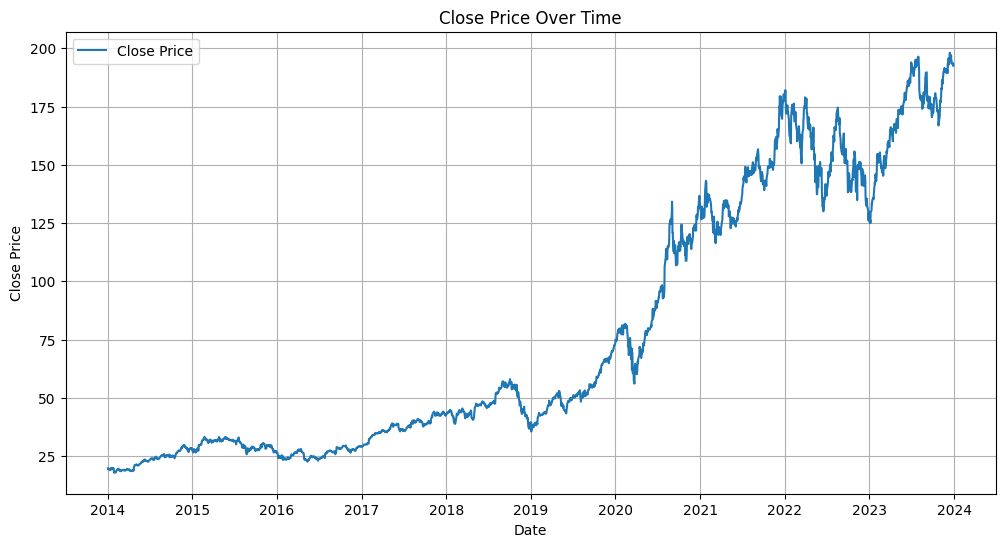

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['close'], label='Close Price')
plt.title('Close Price Over Time')
plt.xlabel('Date')  
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df = df.dropna(subset=['log_return'])

#Future return will be used to calculate the trend
df['future_return'] = df['log_return'].shift(-1)
df = df.dropna(subset=['future_return'])

#Create trend as target variable

df['trend'] = df['future_return'].apply(lambda x: 1 if x > 0 else 0)
df['trend'] = df['trend'].astype('category')
df = df.drop(['future_return'],errors='ignore')


X = df.drop(columns=['trend']) 


df = df.dropna()

X = df.drop(columns=['trend'])
y = df['trend']
#Split the data
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


log_return is calculated in this cell. log_return is basically the percentage change in price from one day to the next. ML models usually perform better when using returns instead of raw prices. This leads into the creation of future_return, which is the next days log return. Trend, which is the target variable, is then created will return as 1 if the next days log_return is positive and 0 if the next days return is negative (uptrend or downtrend) NAN rows are dropped and then the data is split chornologically. 

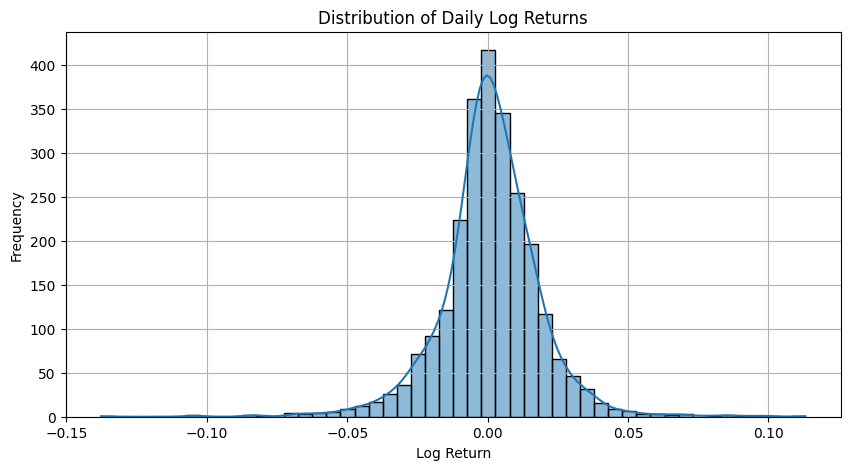

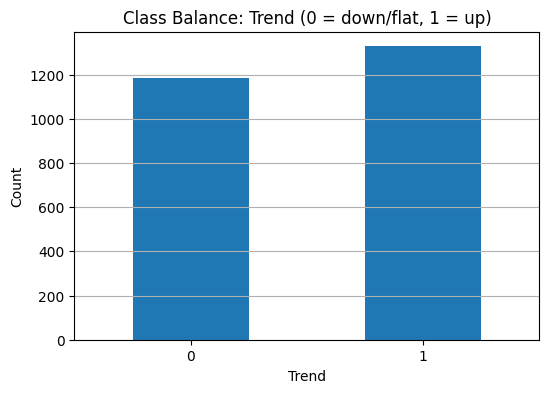

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['log_return'], bins=50, kde=True)
plt.title('Distribution of Daily Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency') 
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
df['trend'].value_counts().sort_index().plot(kind='bar') 
plt.title('Class Balance: Trend (0 = down/flat, 1 = up)')
plt.xlabel('Trend') 
plt.ylabel('Count') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [11]:
#Featurecell

class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self

    def transform(self, X):       
        X = X.copy()

        #Returns
        X['return_1d'] = X['close'].pct_change()
        if 'log_return' not in X.columns:
            X['log_return'] = np.log(X['close'] / X['close'].shift(1))

        #Trend features - Moving averages
        rolling_20 = X['close'].rolling(window=20)
        rolling_14 = X['close'].rolling(window=14)

        X['sma_20'] = rolling_20.mean()
        X['ema_50'] = X['close'].ewm(span=50, adjust=False).mean()

        X['price_sma20_ratio'] = X['close'] / X['sma_20']

        #Volatility features
        X['volatility_14'] = rolling_14.std()
        high_low = X['high'] - X['low']
        high_close = (X['high'] - X['close'].shift(1)).abs()
        low_close = (X['low'] -X['close'].shift(1)).abs()
        true_range = np.maximum(high_low, np.maximum(high_close, low_close))
        X['atr_14'] = pd.Series(true_range, index=X.index).rolling(14).mean()

        #Bollinger Bands
        X['bollinger_upper'] = rolling_20.mean() + (2 * rolling_20.std())
        X['bollinger_lower'] = rolling_20.mean() - (2 * rolling_20.std())
        X['bollinger_width'] = (X['bollinger_upper'] - X['bollinger_lower']) / X['sma_20']
        
        #Macd
        ema_12 = X['close'].ewm(span=12, adjust=False).mean()
        ema_26 = X['close'].ewm(span=26, adjust=False).mean()
        X['macd'] = ema_12 - ema_26
        X['macd_signal'] = X['macd'].ewm(span=9, adjust=False).mean()

       #Volume
        X['volume_change'] = X['volume'].pct_change()
        X['volume_ma_5'] = X['volume'].rolling(window=5).mean()
        X['volume_ratio'] = X['volume'] / X['volume_ma_5']
    
        #Lag features for returns
        for lag in range(1, 6):
           X[f'return_lag_{lag}'] = X['log_return'].shift(lag)

        #Rate of change
        X['roc_10'] = X['close'].pct_change(10)
        X['roc_20'] = X['close'].pct_change(20)

        #RSI calculation
        delta = X['close'].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = -delta.clip(upper=0).rolling(14).mean()
        rs = gain / loss
        X['rsi_14'] = 100 - (100 / (1 + rs))

        

        
        feature_cols = [col for col in X.columns if col != 'trend']
        X[feature_cols] = X[feature_cols].shift(1)
        return X


#Preprocessing and modeling pipeline
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
    }

#Hyperparameter grids for each model
param_grids = {
    'Logistic Regression': {
        'model__C': [20, 30, 40],
        'model__solver': ['lbfgs', 'liblinear'],
        'model__class_weight': [None, 'balanced']
    },
    'Random Forest' : {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [None, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None],
        'model__bootstrap': [True, False]
    },
    'XGBoost': {
        'model__n_estimators': [500, 800, 1000],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [6, 8, 10],
        'model__min_child_weight': [1, 3, 5],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
        'model__gamma': [0, 0.1, 0.2, 0.3]
    },
    'CatBoost': {
        'model__iterations': [500, 1500],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__depth': [6, 8, 10],
        'model__l2_leaf_reg': [1, 10],
        'model__border_count': [32, 64, 128],
    }
        
}
    



return_1d: 1 day percentage return form close
lag features: return_lag_1 to return_lag_5 are lagged log returns used to capture short term momentum whithin the stock. 
sma_20: 20 day simple moving average of close
ema_50: 50 day exponential moving average of close. 
price_sma20_ratio: price relative to its 20 day SMA. 
-These features show the price trend and the ratio shows how far the price is from the trend. 
volatility_14: A 14 day rolling std of close.
atr_14: 14 day Average True Range, which combines high, low, close to measure price range. Essentially capturing intraday movement. 
bollinger_upper and bollinger_lower: Represented as three lines. The center is the stocks 20 day SMA, the upper band is usually two standar deviations above the center line, the lower is usually two standard deviations from the bottom. The bands widen when the price is more volitile and contract when its more stable. When the price nears the upper band, the stock is usually overbought, and is oversold when it nears the lower band which would be a signal to buy. 
bollinger_width: Measures volatility by calculating the distance between the upper and lower bands. 
- These features are important becuse they measure volatility and indicate buy or sell for certain prices. 
macd:Moving average convergence divergence is calculated by subtracting the 26 day EMA from the 12 day EMA which created the macd line. The signal line is the 9 day ema of the macd line and when its plotted on top of the the macd line is can give buy signals (usally when the macd line crossed above the signal line) and sell signals (wehn the line crossed below the signal)
-This feature is another way to track and predict trends
Volume: Volume is basically the number of shares traded in the stock over a specific period of time. volume_change is the percentage change in volume, volume_ma_5 is the 5 day moving average of volume, and volume_ratio is the volume relative to the 5 day average. 
- Volume is used to indicate bullish or bearish beahavior in a stock. Usually by visual indicators in the volume graph like: head and shoulders pattern, or flag and pennant patterns. 
roc_10 and roc_20: 10 and 20 day percentage change in the close price. 
- Shows the momentum of the stock price. 
RSI: Relative Strength Index measures the speed and change of price movements on a scale from 0 - 100. An RSI above 70 usually indicates the stock is overbought and below 30 indicates oversold. It is calculated by the average gain and loss over a specific time, usually 14 days. 
- RSI is another way to identify trends in data and find buy or sell points. 


In [12]:
#Cross-Validation and GridSearchCV
tscv = TimeSeriesSplit(n_splits=5, gap=5)

best_models = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")  
    pipeline = Pipeline([
        ('feature_engineering', FeatureEngineeringTransformer()),
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    random_search = RandomizedSearchCV(
        pipeline, param_grids[model_name], 
        cv=tscv, scoring='roc_auc', n_jobs=-1, error_score='raise'
    )   
    random_search.fit(X_train, y_train)

    best_models[model_name] = random_search.best_estimator_
    
    filepath = f'best_{model_name.replace(" ", "_").lower()}_pipeline.pkl'
    joblib.dump(random_search.best_estimator_, filepath)
    print(f'Saved best {model_name} pipeline to {filepath}')
    
    y_pred = random_search.best_estimator_.predict(X_test)
    print(f"Best parameters for {model_name}: {random_search.best_params_}")
    print(f"Classification Report for {model_name}:") 
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Confusion Matrix for {model_name}:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")
   

Training Logistic Regression...
Saved best Logistic Regression pipeline to best_logistic_regression_pipeline.pkl
Best parameters for Logistic Regression: {'model__solver': 'lbfgs', 'model__class_weight': 'balanced', 'model__C': 40}
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.50      0.30      0.37       246
           1       0.51      0.71      0.60       257

    accuracy                           0.51       503
   macro avg       0.51      0.50      0.48       503
weighted avg       0.51      0.51      0.49       503

Confusion Matrix for Logistic Regression:
[[ 73 173]
 [ 74 183]]


Training Random Forest...
Saved best Random Forest pipeline to best_random_forest_pipeline.pkl
Best parameters for Random Forest: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 30, 'model__bootstrap': True}
Classification Report for 

Timeseriessplit is used so that earlier data is used for training and later data is used for validation. The gap between training and validation is to prevent leakage. 
Models include: Logistic Regression, Random Forest XGBoost, and CATBoost. RandomizedSearchCV was used to reduce computing time, roc_auc is used for scoring. 

ROC-AUC: 0.51


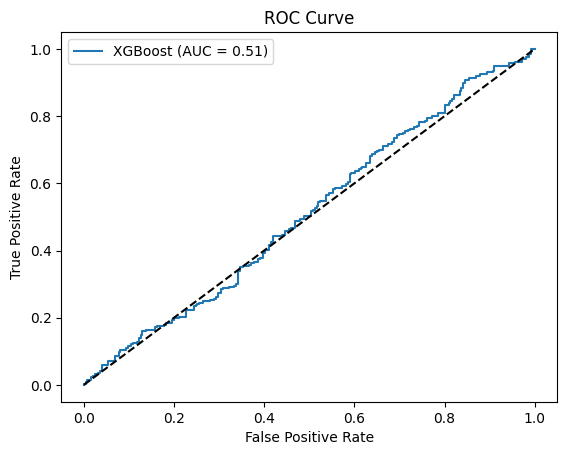

In [13]:
y_pred_proba = best_models['XGBoost'].predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {roc_auc:.2f}')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate')
plt.title('ROC Curve') 
plt.legend()
plt.show()